In [1]:
import cfe
import pandas as pd
import scanpy as sc


cfe.logger.setLevel("INFO")
cfe.settings.backend = "python_function"

[2025年04月15日 18时12分04秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

## Data

In [2]:
# creating from Anndata
adata = sc.read_h5ad(f"../../tests/data/bifurcating.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["counts"] = fadata.X.copy()
fadata.layers["expression"] = fadata.X.copy()

cluster_key = "lineage"
fadata.obs.index = fadata.obs["cell_id"].tolist()

fadata

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'counts', 'expression'

## Method

In [3]:
method = cfe.method.FateMethod(method_name="paga")
method

[2025年04月15日 18时12分11秒] INFO     Loaded function: <function cf_paga at 0x76e3ad7d5d80> from                  
                                       /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_paga.py              
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76e3acd07850>                                                                   


In [4]:
# PAGA need more prior information and parameters
prior_information = {"start_id": "cell1", "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.5}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
method.infer_trajectory(fadata, parameters=parameters)  # add parameters when inferring trajectory

Normalized count data: X, spliced, unspliced.
Logarithmized X.


## Plot

<Axes: title={'center': 'lineage'}, xlabel='UMAP1', ylabel='UMAP2'>

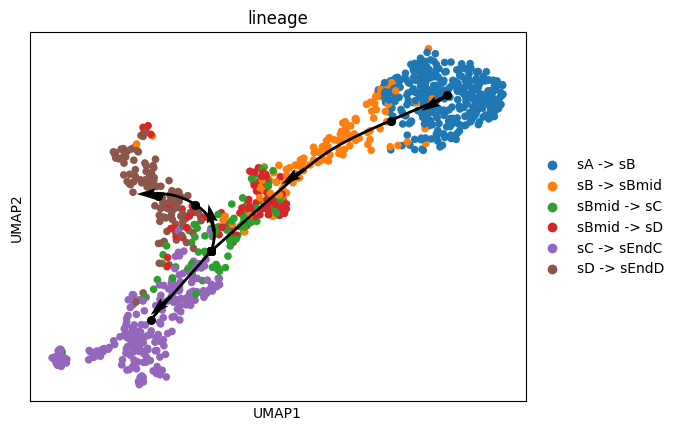

In [5]:
cfe.plot.plot_trajectory(fadata, basis="umap", color="lineage")

## Save

In [6]:
# TODO
# fadata.write_h5ad("output.h5ad")

In [7]:
fadata

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'counts', 'expression'

In [30]:
fadata.obs

,cell_id,from,to,time,lineage,global_time,lin_time_sC -> sEndC,lin_time_sA -> sB,lin_time_sB -> sBmid,lin_time_sBmid -> sC,lin_time_sD -> sEndD,lin_time_sBmid -> sD
cell1,cell1,sC,sEndC,0.629863,sC -> sEndC,3.629863,0.629863,NaN,NaN,NaN,NaN,NaN
cell2,cell2,sA,sB,0.624213,sA -> sB,0.624213,NaN,0.624213,NaN,NaN,NaN,NaN
cell3,cell3,sC,sEndC,0.935012,sC -> sEndC,3.935012,0.935012,NaN,NaN,NaN,NaN,NaN
cell4,cell4,sB,sBmid,0.778926,sB -> sBmid,1.778926,NaN,NaN,0.778926,NaN,NaN,NaN
cell5,cell5,sBmid,sC,0.199444,sBmid -> sC,2.199444,NaN,NaN,NaN,0.199444,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
cell996,cell996,sC,sEndC,0.335488,sC -> sEndC,3.335488,0.335488,NaN,NaN,NaN,NaN,NaN
cell997,cell997,sA,sB,0.712222,sA -> sB,0.712222,NaN,0.712222,NaN,NaN,NaN,NaN
cell998,cell998,sC,sEndC,0.616593,sC -> sEndC,3.616593,0.616593,NaN,NaN,NaN,NaN,NaN
cell999,cell999,sA,sB,0.788889,sA -> sB,0.788889,NaN,0.788889,NaN,NaN,NaN,NaN


In [29]:
fadata.uns["cfe"]

{'prior_information': {'start_id': 'cell1',
  'groups_id': ['sC -> sEndC',
   'sA -> sB',
   'sC -> sEndC',
   'sB -> sBmid',
   'sBmid -> sC',
   'sD -> sEndD',
   'sA -> sB',
   'sB -> sBmid',
   'sBmid -> sC',
   'sBmid -> sD',
   'sD -> sEndD',
   'sA -> sB',
   'sB -> sBmid',
   'sA -> sB',
   'sBmid -> sC',
   'sBmid -> sD',
   'sB -> sBmid',
   'sB -> sBmid',
   'sA -> sB',
   'sBmid -> sC',
   'sBmid -> sD',
   'sA -> sB',
   'sB -> sBmid',
   'sB -> sBmid',
   'sBmid -> sD',
   'sA -> sB',
   'sD -> sEndD',
   'sA -> sB',
   'sD -> sEndD',
   'sBmid -> sD',
   'sBmid -> sD',
   'sBmid -> sC',
   'sC -> sEndC',
   'sC -> sEndC',
   'sC -> sEndC',
   'sA -> sB',
   'sC -> sEndC',
   'sB -> sBmid',
   'sD -> sEndD',
   'sA -> sB',
   'sBmid -> sC',
   'sC -> sEndC',
   'sBmid -> sC',
   'sBmid -> sC',
   'sBmid -> sD',
   'sA -> sB',
   'sA -> sB',
   'sA -> sB',
   'sD -> sEndD',
   'sD -> sEndD',
   'sB -> sBmid',
   'sA -> sB',
   'sB -> sBmid',
   'sA -> sB',
   'sC -> sEndC'

In [23]:
fadata.uns["cfe"]["trajectory_history_dict"]

{'20250407_163819__paga-python_function__hMWFRFJtgS': {'milestone_wrapper': <cfe.data.fate_milestone_wrapper.MilestoneWrapper at 0x70b4d9f2fb20>,
  'raw_wrapper_dict': {},
  'waypoint_wrapper': <cfe.data.fate_waypoint_wrapper.WaypointWrapper at 0x70b4d8b4fa30>}}

In [24]:
milestone_obj = fadata.uns["cfe"]["trajectory_history_dict"]["20250407_163819__paga-python_function__hMWFRFJtgS"][
    "milestone_wrapper"
]
milestone_obj

In [28]:
milestone_obj.keys()

dict_keys(['id', 'milestone_network', 'id_list', 'divergence_regions', 'cell_id_list', 'milestone_percentages', 'progressions', 'milestone_network_class', 'directed'])

In [26]:
for i in milestone_obj.keys():
    print(f"{i} is :\n{milestone_obj[i]}\n")

id is :
20250407_163822__MilestoneWrapper__wQ6aTqQvKb

milestone_network is :
  from to    length  directed
0    1  5  0.225062      True
1    2  3  0.693092      True
2    3  1  0.341110      True
3    1  1  0.281686      True
4    4  6  0.236878      True
5    1  4  0.185350      True

id_list is :
['1', '5', '2', '3', '4', '6']

divergence_regions is :
Empty DataFrame
Columns: [divergence_id, milestone_id, is_start]
Index: []

cell_id_list is :
Index(['cell1', 'cell2', 'cell3', 'cell4', 'cell5', 'cell6', 'cell7', 'cell8',
       'cell9', 'cell10',
       ...
       'cell991', 'cell992', 'cell993', 'cell994', 'cell995', 'cell996',
       'cell997', 'cell998', 'cell999', 'cell1000'],
      dtype='object', length=1000)

milestone_percentages is :
       cell_id milestone_id  percentage
0        cell5            1    1.000000
1        cell9            1    1.000000
2       cell15            1    1.000000
3       cell20            1    1.000000
4       cell32            1    1.000000
...